In [1]:
#LOAD NECESSARY MODULES
import os
import numpy as np
import pandas as pd
import MDAnalysis as mda
from MDAnalysis.analysis import rms
import matplotlib.pyplot as plt

In [17]:
# Selected topology and trajectory
topology_file = "frame0.pdb"
trajectory_file = "prod_noW.xtc"

In [18]:
u = mda.Universe(topology_file, trajectory_file)
print(u)
print("Number of atoms/beads:", len(u.atoms))
print("Number of residues:", len(u.residues))
print("Number of frames:", len(u.trajectory))

C:\Users\Alam Hidayat\miniconda3\Lib\site-packages\MDAnalysis\topology\PDBParser.py:331: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using MDAnalysis.topology.guessers.
  warnings.warn("Element information is missing, elements attribute "
C:\Users\Alam Hidayat\miniconda3\Lib\site-packages\MDAnalysis\topology\guessers.py:146: UserWarning: Failed to guess the mass for the following atom types: A
  warnings.warn("Failed to guess the mass for the following atom types: {}".format(atom_type))
C:\Users\Alam Hidayat\miniconda3\Lib\site-packages\MDAnalysis\topology\guessers.py:146: UserWarning: Failed to guess the mass for the following atom types: D
  warnings.warn("Failed to guess the mass for the following atom types: {}".format(atom_type))
C:\Users\Alam Hidayat\miniconda3\Lib\site-packages\MDAnalysis\topology\guessers.py:146: UserWarning: Failed to guess the mass for the following atom types: E
  warnings.warn("Failed

<Universe with 4360 atoms>
Number of atoms/beads: 4360
Number of residues: 469
Number of frames: 201


In [19]:
ig_resid_range = "3:89"     # Edit here if needed
tm_resid_range = "108:128"  # Edit here if needed

ig_domain = u.select_atoms(f"resid {ig_resid_range}")
tm_helix = u.select_atoms(f"resid {tm_resid_range}")

print("Ig domain beads:", len(ig_domain), "residues:", len(ig_domain.residues))
print("TM helix beads:", len(tm_helix), "residues:", len(tm_helix.residues))
print("Ig residues:", ig_domain.residues.resids.min(), "to", ig_domain.residues.resids.max())
print("TM residues:", tm_helix.residues.resids.min(), "to", tm_helix.residues.resids.max())

Ig domain beads: 198 residues: 87
TM helix beads: 41 residues: 21
Ig residues: 3 to 89
TM residues: 108 to 128


,frame,time_ps,rmsd_A,time_ns
0,0.0,0.0,6.031566e-07,0.0
1,1.0,100.0,2.149556e+00,0.1
2,2.0,200.0,2.308411e+00,0.2
3,3.0,300.0,3.628202e+00,0.3
4,4.0,400.0,3.824889e+00,0.4


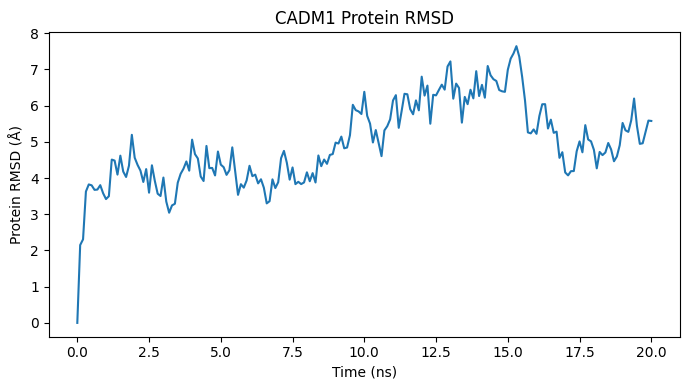

In [20]:
rmsd_analysis = rms.RMSD(
    u,
    u,
    select="resid 1-138",
    ref_frame=0
)
rmsd_analysis.run()

rmsd_df = pd.DataFrame(
    rmsd_analysis.results.rmsd,
    columns=["frame", "time_ps", "rmsd_A"]
)
rmsd_df["time_ns"] = rmsd_df["time_ps"] / 1000.0

display(rmsd_df.head())

plt.figure(figsize=(7, 4))
plt.plot(rmsd_df["time_ns"], rmsd_df["rmsd_A"])
plt.xlabel("Time (ns)")
plt.ylabel("Protein RMSD (Å)")
plt.title("CADM1 Protein RMSD")
plt.tight_layout()
plt.show()

In [21]:
z_axis = np.array([0.0, 0.0, 1.0])

def unit_vector(v):
    return v / np.linalg.norm(v)

def angle_between_vectors(v1, v2):
    v1 = unit_vector(v1)
    v2 = unit_vector(v2)
    cosang = np.dot(v1, v2)
    # We use abs(cosang) because an axis has arbitrary direction sign
    cosang = np.clip(abs(cosang), -1.0, 1.0)
    angle = np.degrees(np.arccos(cosang))
    return angle

def split_selection_by_resid(atomgroup):
    residues = atomgroup.residues
    resids = residues.resids
    midpoint = np.median(resids)
    lower = atomgroup.select_atoms(f"resid {resids.min()}:{int(midpoint)}")
    upper = atomgroup.select_atoms(f"resid {int(midpoint)+1}:{resids.max()}")
    return lower, upper

def axis_from_split(atomgroup):
    lower, upper = split_selection_by_resid(atomgroup)
    lower_center = lower.center_of_geometry()
    upper_center = upper.center_of_geometry()
    # Vector from lower half to upper half
    return upper_center - lower_center

In [22]:
membrane_normal = z_axis
records = []

for ts in u.trajectory:
    ig_axis = axis_from_split(ig_domain)
    tm_axis = axis_from_split(tm_helix)
    
    ig_vs_z = angle_between_vectors(ig_axis, membrane_normal)
    ig_vs_tm = angle_between_vectors(ig_axis, tm_axis)
    tm_vs_z = angle_between_vectors(tm_axis, membrane_normal)
    
    records.append({
        "frame": ts.frame,
        "time_ps": ts.time,
        "time_ns": ts.time / 1000.0,
        "ig_vs_z_deg": ig_vs_z,
        "ig_vs_tm_deg": ig_vs_tm,
        "tm_vs_z_deg": tm_vs_z,
    })

angles_df = pd.DataFrame(records)
#display(angles_df.head())

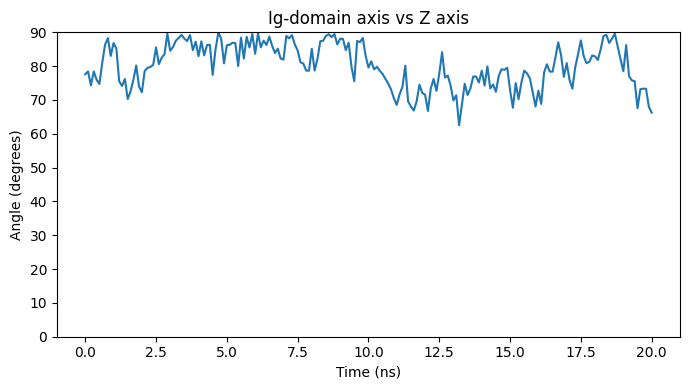

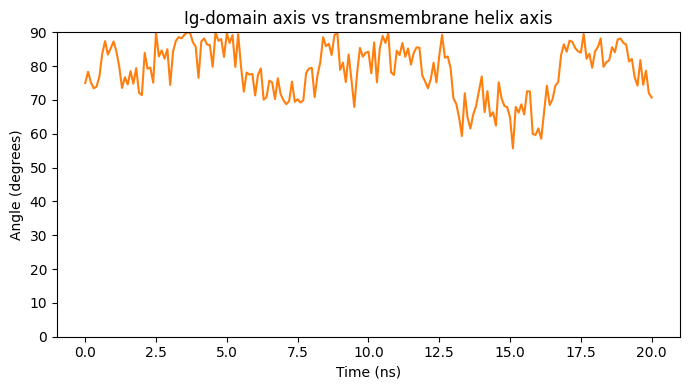

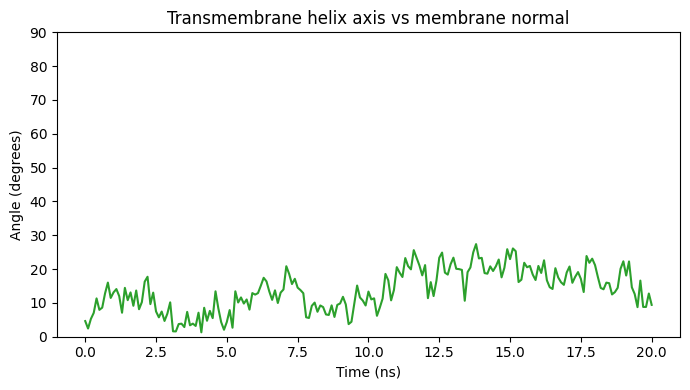

In [23]:
plt.figure(figsize=(7, 4))
plt.plot(angles_df["time_ns"], angles_df["ig_vs_z_deg"], color="tab:blue")
plt.xlabel("Time (ns)")
plt.ylabel("Angle (degrees)")
plt.title("Ig-domain axis vs Z axis")
plt.ylim(0, 90)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(angles_df["time_ns"], angles_df["ig_vs_tm_deg"], color="tab:orange")
plt.xlabel("Time (ns)")
plt.ylabel("Angle (degrees)")
plt.title("Ig-domain axis vs transmembrane helix axis")
plt.ylim(0, 90)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(angles_df["time_ns"], angles_df["tm_vs_z_deg"], color="tab:green")
plt.xlabel("Time (ns)")
plt.ylabel("Angle (degrees)")
plt.title("Transmembrane helix axis vs membrane normal")
plt.ylim(0, 90)
plt.tight_layout()
plt.show()